# **Short Term Load Prediction with ML&Ai**
## Techniques Used:
   *  KAN (Kolmogorov-Arnold Networks) - White Box
   *  ANN (Artificial Neural Network) - Residual Error Handler

## All imports used throughout the project

In [78]:
!pip install pykan
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import sympy
import random
from kan import KAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Locking down the random seed

In [79]:
#Locking Random Seeds for Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seeds locked to 42")

Random seeds locked to 42


## Data Pre Processing

### Dataset Adjustment

In [80]:
#Load the Data
df_load = pd.read_csv('/kaggle/input/datasets/yug201/delhi-5-minute-electricity-demand-for-forecasting/powerdemand_5min_2021_to_2024_with weather.csv')

# Convert the 'datetime' column to datetime objects and set it as the index
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_load = df_load.set_index('datetime')

#Combine the 5 min data into 1H blocks
df_hourly_load = df_load.resample('1h').mean()
# Make the data as needed. In my case mostly Temparature and Day of the week
df_hourly_load['Hour'] = df_hourly_load.index.hour
df_hourly_load['Day of the week'] = df_hourly_load.index.dayofweek
# Drop any points where the grid might have been offline or shut down
df_hourly_load = df_hourly_load.dropna()

print(df_hourly_load.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33062 entries, 2021-01-01 00:00:00 to 2024-12-12 00:00:00
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       33062 non-null  float64
 1   Power demand     33062 non-null  float64
 2   temp             33062 non-null  float64
 3   dwpt             33062 non-null  float64
 4   rhum             33062 non-null  float64
 5   wdir             33062 non-null  float64
 6   wspd             33062 non-null  float64
 7   pres             33062 non-null  float64
 8   year             33062 non-null  float64
 9   month            33062 non-null  float64
 10  day              33062 non-null  float64
 11  hour             33062 non-null  float64
 12  minute           33062 non-null  float64
 13  moving_avg_3     33062 non-null  float64
 14  Hour             33062 non-null  int32  
 15  Day of the week  33062 non-null  int32  
dtypes: float64(14), int32(2

### Adjusting Data for the KAN

In [81]:
#Only Keeping the selectfew needed attributes
features_needed = ['Power demand', 'temp', 'rhum', 'month', 'Hour', 'Day of the week']
df_clean = df_hourly_load[features_needed].copy() #copying from the preprocessed data

df_clean.columns = ['Load', 'Temperature', 'Humidity', 'Month', 'Hour', 'DayOfWeek'] #making the titles more readable
df_clean = df_clean.ffill()# Filling any missing values using forward fill

#Train Test split, splitting off 20% for test, 80% training
split_idx = int(len(df_clean) * 0.8)
train_data = df_clean.iloc[:split_idx] #Tarining Data
test_data = df_clean.iloc[split_idx:] # Test Data

#Separate X (Inputs) and Y (Target)
X_train = train_data.drop(columns=['Load'])
y_train = train_data[['Load']]

X_test = test_data.drop(columns=['Load'])
y_test = test_data[['Load']]

#Create Standard Scaler objects for the data fitting
# z = (x-mean)/standard deviation
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

#Fitting the data into scaled datasets
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train)
y_test_scaled = scaler_Y.transform(y_test)


print(f"Training shapes -> X: {X_train_scaled.shape}, Y: {y_train_scaled.shape}")
print(f"Testing shapes  -> X: {X_test_scaled.shape}, Y: {y_test_scaled.shape}")
print("Data Processed!")

Training shapes -> X: (26449, 5), Y: (26449, 1)
Testing shapes  -> X: (6613, 5), Y: (6613, 1)
Data Processed!


### Converting Data for Pytorch and initializing the KAN model

In [82]:
# 1. Detect the Kaggle GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}") # This must print 'cuda' if the Kaggle GPU is on!

# 2. Convert to Tensors AND push them to the GPU using .to(device)
train_input_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
train_label_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

test_input_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
test_label_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# 3. Package into the pykan dictionary
dataset = {
    'train_input': train_input_tensor,
    'train_label': train_label_tensor,
    'test_input': test_input_tensor,
    'test_label': test_label_tensor
}

print("PyTorch Tensors Created and moved to GPU")

Using device: cuda
PyTorch Tensors Created and moved to GPU


## KAN Model Creation and Training

### Model Initialization

In [83]:
# Initializing the KAN Model on the GPU
# width = [Inputs, Hidden Nodes, Outputs]
# We have 5 inputs (Temp, Hum, Month, Hour, Day)
model = KAN(width=[5, 10, 1], grid=5, k=3, seed=seed, device=device)

print("KAN Model Initialized Successfully")

checkpoint directory created: ./model
saving model version 0.0
KAN Model Initialized Successfully


### KAN Model Training

In [84]:
# Loss function (Mean Squared Loss)
loss_fn = torch.nn.MSELoss()

#Tarining the model
print("Starting Training...")
results = model.fit(dataset, opt="LBFGS", steps=500, loss_fn=loss_fn)
print(f"Final Training Loss: {results['train_loss'][-1]:.4f}")
print(f"Final Testing Loss:  {results['test_loss'][-1]:.4f}")
print("Training Complete!")

Starting Training...


| train_loss: 6.88e-01 | test_loss: 9.98e-01 | reg: 4.71e+01 | : 100%|█| 500/500 [02:53<00:00,  2.88

saving model version 0.1
Final Training Loss: 0.6881
Final Testing Loss:  0.9978
Training Complete!


## Residual Calculation and Visualisation

In [85]:
# Calculations

# Asking the model to predict the test dataset
with torch.no_grad(): # We turn off gradients as we're just predicting not training
    predictions_scaled = model(test_input_tensor)

# Converting PyTorch tensors back to standard NumPy arrays
# FIX: Added .cpu() to bring data off the GPU before converting to NumPy
predictions_scaled = predictions_scaled.cpu().numpy()
actuals_scaled = test_label_tensor.cpu().numpy()

# Inverse Transforming scaled items back to original values
# Convert the scaled numbers (e.g: 1.2) back to real Megawatts (e.g: 6500 MW)
predictions_real = scaler_Y.inverse_transform(predictions_scaled)
actuals_real = scaler_Y.inverse_transform(actuals_scaled)

# Plotting the results (Let's look at a 30-day window ie 720 hours)
hours_to_plot = 720

# Calculating the Residuals (Errors) on the scaled data
# FIX: Added .cpu() here as well!
train_predictions_scaled = model(train_input_tensor).detach().cpu().numpy()
train_actuals_scaled = train_label_tensor.cpu().numpy()

# The formula: Residual = Actual - Prediction
train_residuals = train_actuals_scaled - train_predictions_scaled

test_residuals = actuals_scaled - predictions_scaled
print("Residuals Calculated")

Residuals Calculated


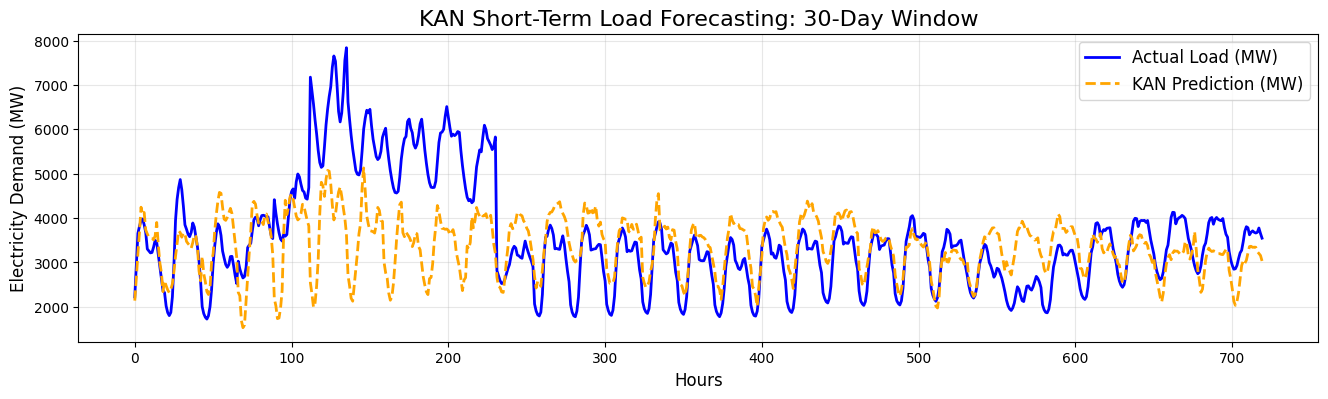

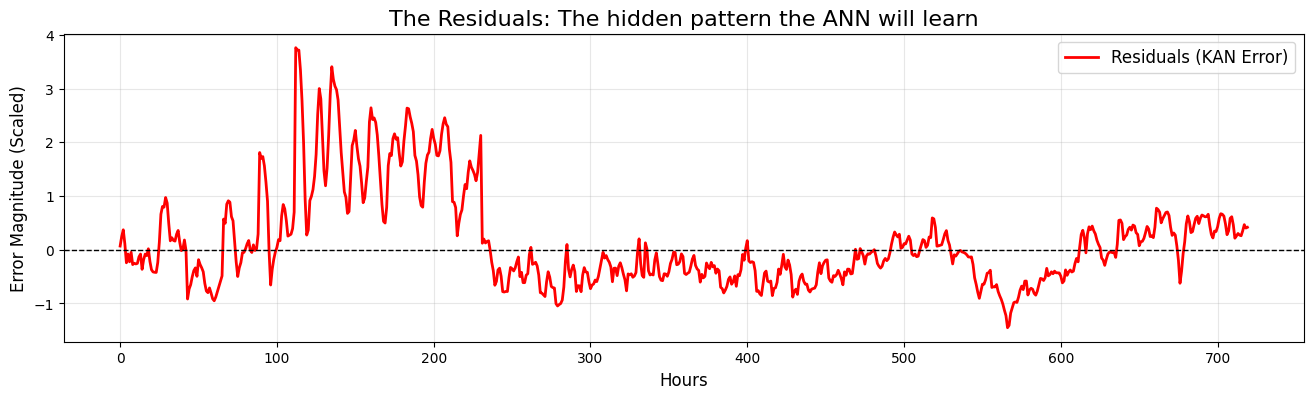

In [86]:
#Visualizing the predictions
plt.figure(figsize=(16, 4))
plt.plot(actuals_real[:hours_to_plot], label="Actual Load (MW)", color='blue', linewidth=2)
plt.plot(predictions_real[:hours_to_plot], label="KAN Prediction (MW)", color='orange', linestyle='dashed', linewidth=2)

plt.title("KAN Short-Term Load Forecasting: 30-Day Window", fontsize=16)
plt.xlabel("Hours", fontsize=12)
plt.ylabel("Electricity Demand (MW)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


#Visualizing what the ANN has to learn (First 30 days of test set)
plt.figure(figsize=(16, 4))
plt.plot(test_residuals[:hours_to_plot], label="Residuals (KAN Error)", color='red', linewidth=2)
plt.axhline(0, color='black', linestyle='dashed', linewidth=1) # The "Perfect Prediction" line
plt.title("The Residuals: The hidden pattern the ANN will learn", fontsize=16)
plt.xlabel("Hours", fontsize=12)
plt.ylabel("Error Magnitude (Scaled)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### KAN BenchMarks

In [87]:
# KAN model evaluation
kan_mse = mean_squared_error(actuals_scaled, predictions_scaled)
kan_mae = mean_absolute_error(actuals_scaled, predictions_scaled)
kan_r2 = r2_score(actuals_scaled, predictions_scaled)

print(f"KAN Model Evaluation on Test Data (Scaled):")
print(f"  Mean Squared Error (MSE): {kan_mse:.4f}")
print(f"  Mean Absolute Error (MAE): {kan_mae:.4f}")
print(f"  R-squared (R2):           {kan_r2:.4f}")

KAN Model Evaluation on Test Data (Scaled):
  Mean Squared Error (MSE): 0.9956
  Mean Absolute Error (MAE): 0.7945
  R-squared (R2):           0.2071


## ANN Implementation

### Data Preparation

In [88]:
#Defining the Memory Window
sequence_length = 72 # 72 hours (3 days) of historical errors

#Sequence Generator Function
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

#Sequential Windows from the KAN's Residuals
X_train_seq, y_train_seq = create_sequences(train_residuals.flatten(), sequence_length)
X_test_seq, y_test_seq = create_sequences(test_residuals.flatten(), sequence_length)

#Formatting Data specifically for an ANN
#ANNs require 2D inputs (Samples, Features
X_train_ann = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_ann = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(-1) # Target remains 1 value

X_test_ann = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_ann = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(-1)

print(f"ANN Training Shape: {X_train_ann.shape}")
print("ANN Data Prepared!")

ANN Training Shape: torch.Size([26377, 72])
ANN Data Prepared!


### ANN Architechture

In [89]:
#Defining the Feedforward ANN Architecture
class ResidualANN(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(ResidualANN, self).__init__()

        #Layer 1: Input to First Hidden Layer
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()

        #Layer 2: Hidden to Second Hidden Layer (Deep Representation)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2 = nn.ReLU()

        #Layer 3: Output Layer (Predicting the single residual error)
        self.fc3 = nn.Linear(hidden_size // 2, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        predictions = self.fc3(x)
        return predictions

#Initializing the Model
input_dim = X_train_ann.shape[1] # Should be our sequence_length (72)
ann_model = ResidualANN(input_size=input_dim, hidden_size=64)

#Defining Optimizer and Loss Function
optimizer_ann = torch.optim.Adam(ann_model.parameters(), lr=0.001)
loss_fn_ann = nn.MSELoss()

print("ANN Architecture Initialized!")

ANN Architecture Initialized!


### ANN Training

In [90]:
#Setting to 500 epochs for a fairly deep analysis
epochs_ann = 500

print("Starting ANN Training to predict KAN residuals...")

for epoch in range(epochs_ann):
    ann_model.train()

    # Forward Pass
    predictions = ann_model(X_train_ann)
    loss = loss_fn_ann(predictions, y_train_ann)

    # Backward Pass (Update Weights ie error reduction)
    optimizer_ann.zero_grad()
    loss.backward()
    optimizer_ann.step()

    # Print Progress
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs_ann}], Loss: {loss.item():.4f}")

print("ANN Training Complete!")

Starting ANN Training to predict KAN residuals...
Epoch [50/500], Loss: 0.1373
Epoch [100/500], Loss: 0.0796
Epoch [150/500], Loss: 0.0607
Epoch [200/500], Loss: 0.0538
Epoch [250/500], Loss: 0.0508
Epoch [300/500], Loss: 0.0494
Epoch [350/500], Loss: 0.0486
Epoch [400/500], Loss: 0.0478
Epoch [450/500], Loss: 0.0473
Epoch [500/500], Loss: 0.0470
ANN Training Complete!


## Hybrid Model Creation And Evaluation

In [91]:
# 1. Put the ANN in evaluation mode
ann_model.eval()

# 2. Make residual predictions on the test set
with torch.no_grad():
    ann_residual_preds = ann_model(X_test_ann).numpy().flatten()

#Align the KAN's base predictions and the Actual Load
#Since the ANN needs 72 hours of history to make its first prediction,
#We must slice off the first 72 hours of the test set to align them.
kan_base_aligned = predictions_scaled[sequence_length:].flatten()

# Note: Ensure 'y_test_scaled' matches the variable name of your scaled test targets!
actual_load_aligned = y_test_scaled[sequence_length:].flatten()

#Combine KAN baseline + ANN error correction
hybrid_ann_predictions = kan_base_aligned + ann_residual_preds

#Calculate Final Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_ann = mean_squared_error(actual_load_aligned, hybrid_ann_predictions)
mae_ann = mean_absolute_error(actual_load_aligned, hybrid_ann_predictions)
r2_ann = r2_score(actual_load_aligned, hybrid_ann_predictions)

print("Hybrid KAN-ANN Model Evaluation on Test Data (Scaled):")
print("-" * 55)
print(f"  Mean Squared Error (MSE): {mse_ann:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_ann:.4f}")
print(f"  R-squared (R2):           {r2_ann:.4f}")

Hybrid KAN-ANN Model Evaluation on Test Data (Scaled):
-------------------------------------------------------
  Mean Squared Error (MSE): 0.0747
  Mean Absolute Error (MAE): 0.1703
  R-squared (R2):           0.9402


## Graphs and Comparison

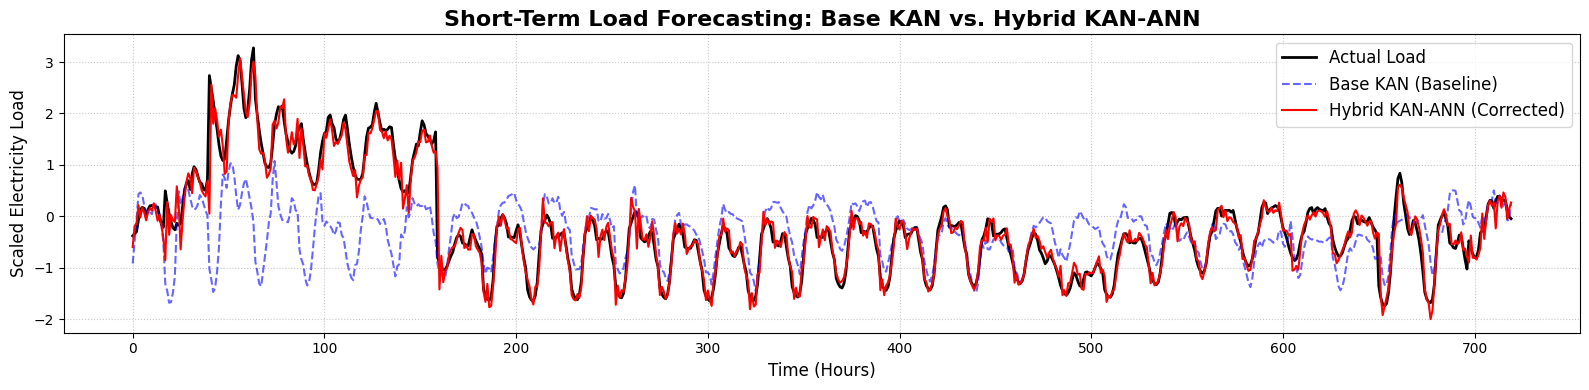


--- Model Benchmarks (Test Data, Scaled) ---
Model                MSE        MAE        R2        
-------------------------------------------------------
KAN                  0.9956     0.7945     0.2071    
Hybrid KAN-ANN       0.0747     0.1703     0.9402    
-------------------------------------------------------


In [92]:
# We will plot a slice of the test data (e.g., the first 300 hours)

plt.figure(figsize=(16, 4))

# 1. Plot the True Data (Black Line)
plt.plot(actual_load_aligned[:hours_to_plot], label='Actual Load', color='black', linewidth=2)

# 2. Plot the Base KAN alone (Blue Dashed Line)
plt.plot(kan_base_aligned[:hours_to_plot], label='Base KAN (Baseline)', color='blue', linestyle='--', alpha=0.6)

# 3. Plot the Hybrid KAN-ANN (Red Line)
plt.plot(hybrid_ann_predictions[:hours_to_plot], label='Hybrid KAN-ANN (Corrected)', color='red', linewidth=1.5)

# Formatting the graph to look academic and professional
plt.title('Short-Term Load Forecasting: Base KAN vs. Hybrid KAN-ANN', fontsize=16, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Scaled Electricity Load', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Show the graph
plt.show()

# Benchmarking comparison
print("\n--- Model Benchmarks (Test Data, Scaled) ---")
print(f"{"Model":<20} {"MSE":<10} {"MAE":<10} {"R2":<10}")
print("-"*55)
print(f"{"KAN":<20} {kan_mse:<10.4f} {kan_mae:<10.4f} {kan_r2:<10.4f}")
print(f"{"Hybrid KAN-ANN":<20} {mse_ann:<10.4f} {mae_ann:<10.4f} {r2_ann:<10.4f}")
print("-"*55)

## The White Box : Extracting Mathematical Formula from the KAN

saving model version 0.2


<Figure size 1000x800 with 0 Axes>

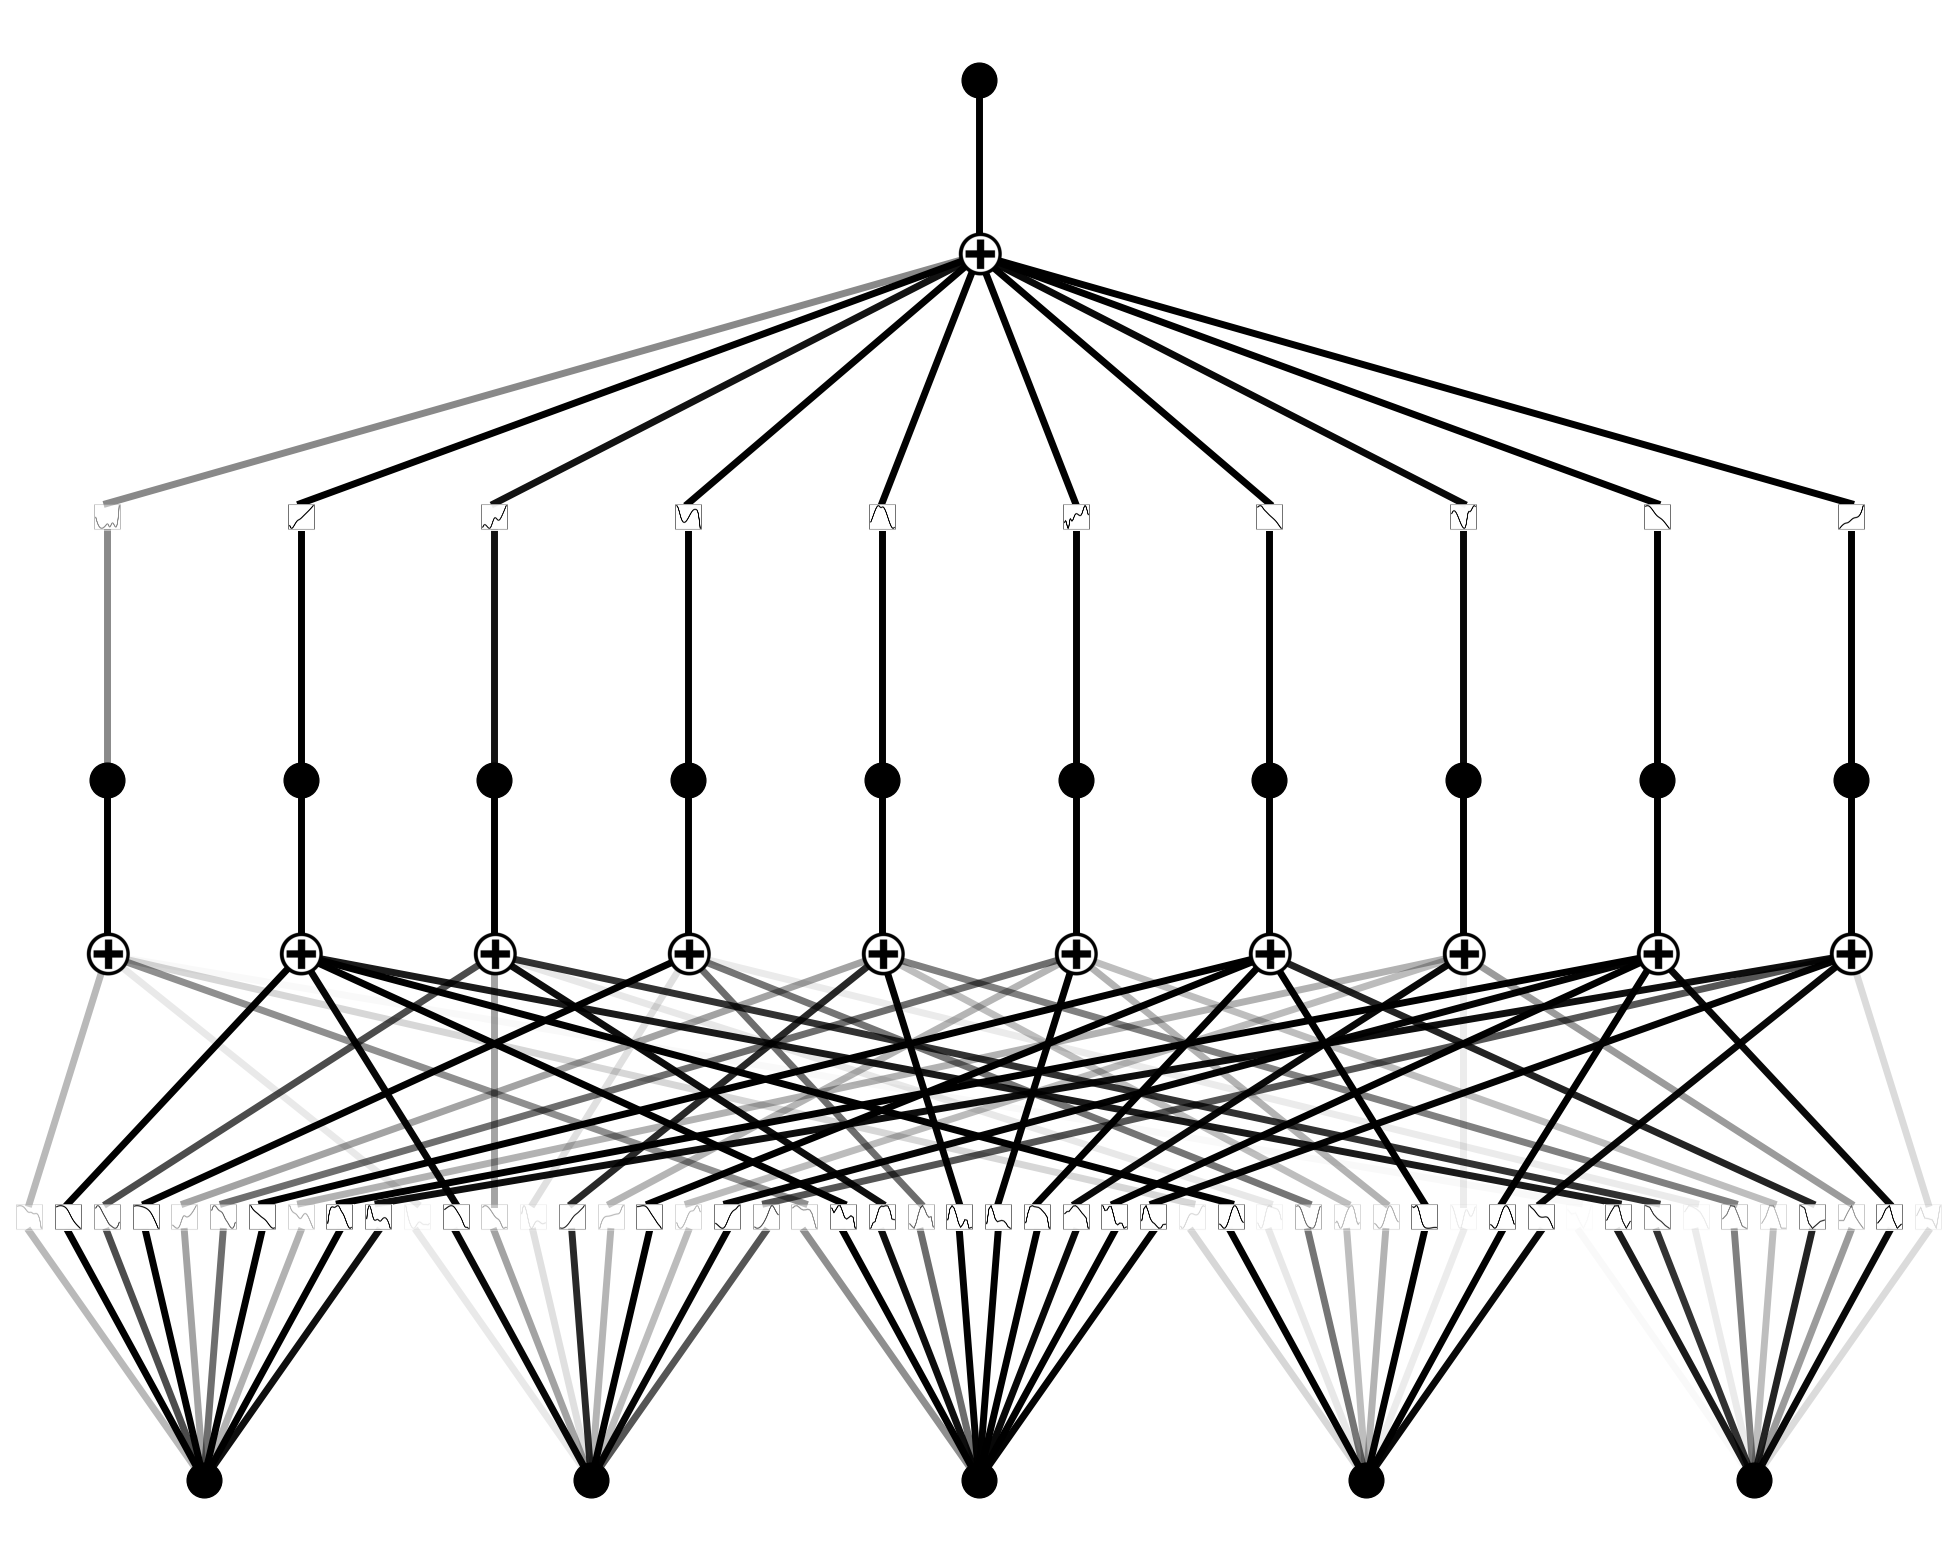

Plot generated on GPU successfully.
fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with cos, r2=0.9979336261749268, c=2
fixing (0,0,2) with sin, r2=0.9984151124954224, c=2
fixing (0,0,3) with exp, r2=0.9974515438079834, c=2
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,0,5) with x, r2=0.9704409241676331, c=1
fixing (0,0,6) with x, r2=0.9903123378753662, c=1
fixing (0,0,7) with 0, r2=0.0, c=0
fixing (0,0,8) with 0, r2=0.0, c=0
fixing (0,0,9) with 0, r2=0.0, c=0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with cos, r2=0.9961414933204651, c=2
fixing (0,1,2) with x, r2=0.9783647060394287, c=1
fixing (0,1,3) with 0, r2=0.0, c=0
fixing (0,1,4) with x, r2=0.9923524856567383, c=1
fixing (0,1,5) with 0, r2=0.0, c=0
fixing (0,1,6) with cos, r2=0.99897301197052, c=2
fixing (0,1,7) with 0, r2=0.0, c=0
fixing (0,1,8) with 0, r2=0.0, c=0
fixing (0,1,9) with 0, r2=0.0, c=0
fixing (0,2,0) with 0, r2=0.0, c=0
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (0,2,2) with 0, r2=0.0, c=0
fixing (0,2,3) w

In [93]:
#Pruning while on GPU
pruned_model = model.prune(node_th=0.001, edge_th=0.001)

#Plotting First to avoid GPU / CPU errors
try:
    plt.figure(figsize=(10,8))
    pruned_model.plot(scale=2.5) 
    plt.savefig('final_whitebox_kan.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot generated on GPU successfully.")
except Exception as e:
    print(f"Plotting failed: {e}")

# 3. NOW move to CPU for the Formula Extraction
pruned_model = pruned_model.cpu()
pruned_model.auto_symbolic()
formula = pruned_model.symbolic_formula()[0][0]

print("\nThe Extracted White-Box Mathematical Formula:")
print("=" * 70)
print(formula)
print("=" * 70)

### Results:
$Base Load Equation = 1.91935228534133*x_1 - 4.14620790988472*cos(0.763919830322266*x_1 - 2.02223968505859) - 1.88088066968626*cos(0.82343989610672*x_2 + 1.3971198797226) + 0.762936536117286*cos(1.01039981842041*x_2 + 1.41791987419128) - 1.83920447090434*cos(1.87263989448547*x_4 - 1.01791989803314) - 1.17774056711639 $

# Test Area